### Project Plan

To answer Kavya's questions, we'll follow these steps:

1.  **Data Loading**: Load the historical sales data into a pandas DataFrame.
2.  **Data Understanding and Cleaning**: Examine the data for missing values, incorrect data types, and any anomalies. Clean the data as necessary.
3.  **Exploratory Data Analysis (EDA)**:
    *   **Growth Analysis**: Analyze sales trends over time to determine if the cafe is growing.
    *   **Peak Times Analysis**: Identify busy periods (e.g., specific hours, days of the week) to understand staff and stock optimization opportunities.
4.  **Forecasting**: Build a model to predict sales for the next fortnight.


In [3]:
project_plan_content = """### Project Plan\n\nTo answer Kavya's questions, we'll follow these steps:\n\n1.  **Data Loading**: Load the historical sales data into a pandas DataFrame.\n2.  **Data Understanding and Cleaning**: Examine the data for missing values, incorrect data types, and any anomalies. Clean the data as necessary.\n3.  **Exploratory Data Analysis (EDA)**: \n    *   **Growth Analysis**: Analyze sales trends over time to determine if the cafe is growing.\n    *   **Peak Times Analysis**: Identify busy periods (e.g., specific hours, days of the week) to understand staff and stock optimization opportunities.\n4.  **Forecasting**: Build a model to predict sales for the next fortnight.\n"""

with open('brewbox_project_plan.md', 'w') as f:
    f.write(project_plan_content)

print('Project plan saved to brewbox_project_plan.md')

Project plan saved to brewbox_project_plan.md


In [4]:
import pandas as pd

# Load the data "brewbox_daily_sales.csv"
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Assignments/Time Series Analysis/brewbox_daily_sales.csv')

# Display the first 5 rows of the DataFrame
display(df.head())

,Date,Day_Name,Cups_Sold,Sales_Rs,Public_Holiday
0,2024-01-01,Monday,86.0,14260.0,No
1,2024-01-02,Tuesday,128.0,20970.0,No
2,2024-01-03,Wednesday,135.0,21340.0,No
3,2024-01-04,Thursday,124.0,20420.0,No
4,2024-01-05,Friday,102.0,15670.0,No


### Data Understanding and Cleaning

Now that the data is loaded, let's inspect it to understand its structure, identify missing values, and prepare it for further analysis.

In [5]:
# 1. Inspect the DataFrame
print('DataFrame Info:')
df.info()

print('\nNumber of Rows and Columns:')
print(f'Rows: {df.shape[0]}, Columns: {df.shape[1]}')

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 685 entries, 0 to 684
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Date            685 non-null    object 
 1   Day_Name        685 non-null    object 
 2   Cups_Sold       671 non-null    float64
 3   Sales_Rs        671 non-null    float64
 4   Public_Holiday  685 non-null    object 
dtypes: float64(2), object(3)
memory usage: 26.9+ KB

Number of Rows and Columns:
Rows: 685, Columns: 5


In [6]:
# Ensure 'Date' column is in datetime format
df['Date'] = pd.to_datetime(df['Date'])

# Get first and last dates
first_date = df['Date'].min()
last_date = df['Date'].max()
print(f'\nFirst Date: {first_date}')
print(f'Last Date: {last_date}')

# Calculate average daily sales
average_daily_sales = df['Sales_Rs'].mean()
print(f'\nAverage Daily Sales: {average_daily_sales:.2f} Rs.')


First Date: 2024-01-01 00:00:00
Last Date: 2025-11-15 00:00:00

Average Daily Sales: 17809.03 Rs.


In [7]:
# Identify missing values
missing_values = df.isnull().sum()
print('\nMissing values per column:')
print(missing_values)

# Dates with missing sales data
missing_sales_dates = df[df['Sales_Rs'].isnull()]['Date']
print('\nDates with missing sales data (billing system went down):')
for date in missing_sales_dates:
    print(date.strftime('%Y-%m-%d'))

# Explanation for Date column
print("\nBefore Python would treat the 'Date' column as a time series, two things had to be done:")
print("1. Convert the column to datetime objects using `pd.to_datetime()`: Initially, the 'Date' column was of object (string) dtype, so it needed to be explicitly converted.")
print("2. Ensure the datetime objects are properly parsed: `pd.to_datetime()` handles various string formats, parsing them into a standardized datetime format.")
print('Inspecting the data first is worth the effort because it helps to identify these data type inconsistencies and potential issues early, preventing errors and ensuring accurate analysis down the line.')


Missing values per column:
Date               0
Day_Name           0
Cups_Sold         14
Sales_Rs          14
Public_Holiday     0
dtype: int64

Dates with missing sales data (billing system went down):
2024-01-19
2024-02-20
2024-03-05
2024-06-15
2024-08-07
2024-09-13
2024-10-17
2024-10-24
2024-11-23
2024-12-05
2025-01-20
2025-02-01
2025-04-08
2025-09-28

Before Python would treat the 'Date' column as a time series, two things had to be done:
1. Convert the column to datetime objects using `pd.to_datetime()`: Initially, the 'Date' column was of object (string) dtype, so it needed to be explicitly converted.
2. Ensure the datetime objects are properly parsed: `pd.to_datetime()` handles various string formats, parsing them into a standardized datetime format.
Inspecting the data first is worth the effort because it helps to identify these data type inconsistencies and potential issues early, preventing errors and ensuring accurate analysis down the line.


In [8]:
# Fill missing values with 0 for Cups_Sold and Sales_Rs
df['Cups_Sold'].fillna(0, inplace=True)
df['Sales_Rs'].fillna(0, inplace=True)

print('\nMissing values after imputation:')
print(df.isnull().sum())

print('\nAll missing values in Cups_Sold and Sales_Rs have been filled with 0, as per the understanding that these dates represent days when the billing system was down and no sales were recorded.')


Missing values after imputation:
Date              0
Day_Name          0
Cups_Sold         0
Sales_Rs          0
Public_Holiday    0
dtype: int64

All missing values in Cups_Sold and Sales_Rs have been filled with 0, as per the understanding that these dates represent days when the billing system was down and no sales were recorded.


/tmp/ipykernel_476/2673376826.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Cups_Sold'].fillna(0, inplace=True)
/tmp/ipykernel_476/2673376826.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.m

In [9]:
import pandas as pd

# Reload the data to ensure df is defined
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Assignments/Time Series Analysis/brewbox_daily_sales.csv')

# Convert 'Date' column to datetime format (as done previously)
df['Date'] = pd.to_datetime(df['Date'])

# Fill missing values with 0 for Cups_Sold and Sales_Rs (as done previously)
df['Cups_Sold'].fillna(0, inplace=True)
df['Sales_Rs'].fillna(0, inplace=True)

print('DataFrame `df` re-initialized and preprocessed.')

DataFrame `df` re-initialized and preprocessed.


/tmp/ipykernel_476/2462841248.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Cups_Sold'].fillna(0, inplace=True)
/tmp/ipykernel_476/2462841248.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df

### 1.2 Exploratory Data Analysis (EDA) - Is my café actually growing?

To determine if the café is growing, we will analyze the sales trends over time.

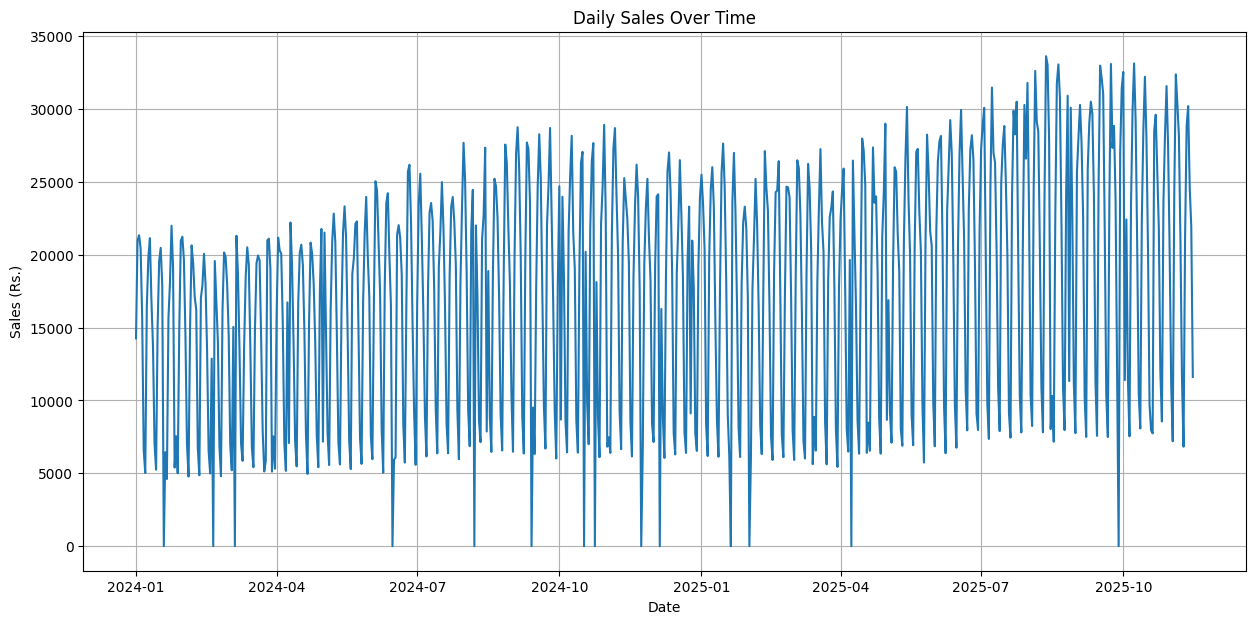

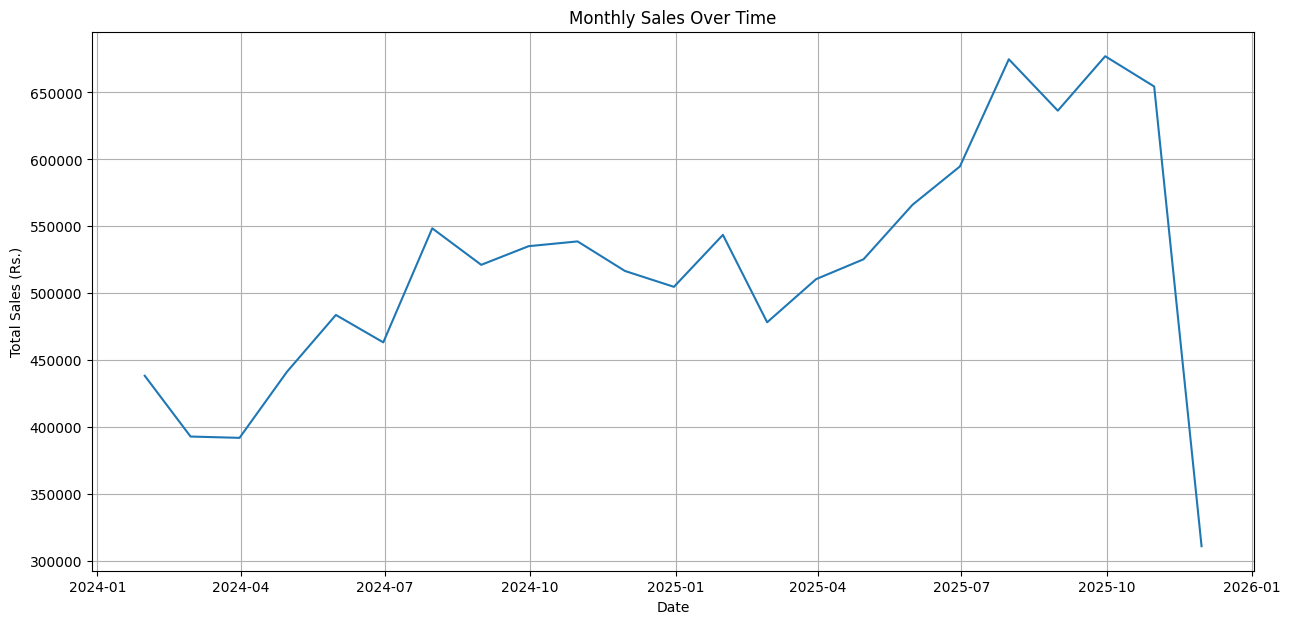

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set 'Date' as the index for time series analysis
df.set_index('Date', inplace=True)

# Plot daily sales over time
plt.figure(figsize=(15, 7))
sns.lineplot(data=df, x=df.index, y='Sales_Rs')
plt.title('Daily Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Sales (Rs.)')
plt.grid(True)
plt.show()

# Resample to a monthly frequency to visualize long-term trends
monthly_sales = df['Sales_Rs'].resample('ME').sum() # Changed 'M' to 'ME'

plt.figure(figsize=(15, 7))
sns.lineplot(data=monthly_sales)
plt.title('Monthly Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Total Sales (Rs.)')
plt.grid(True)
plt.show()

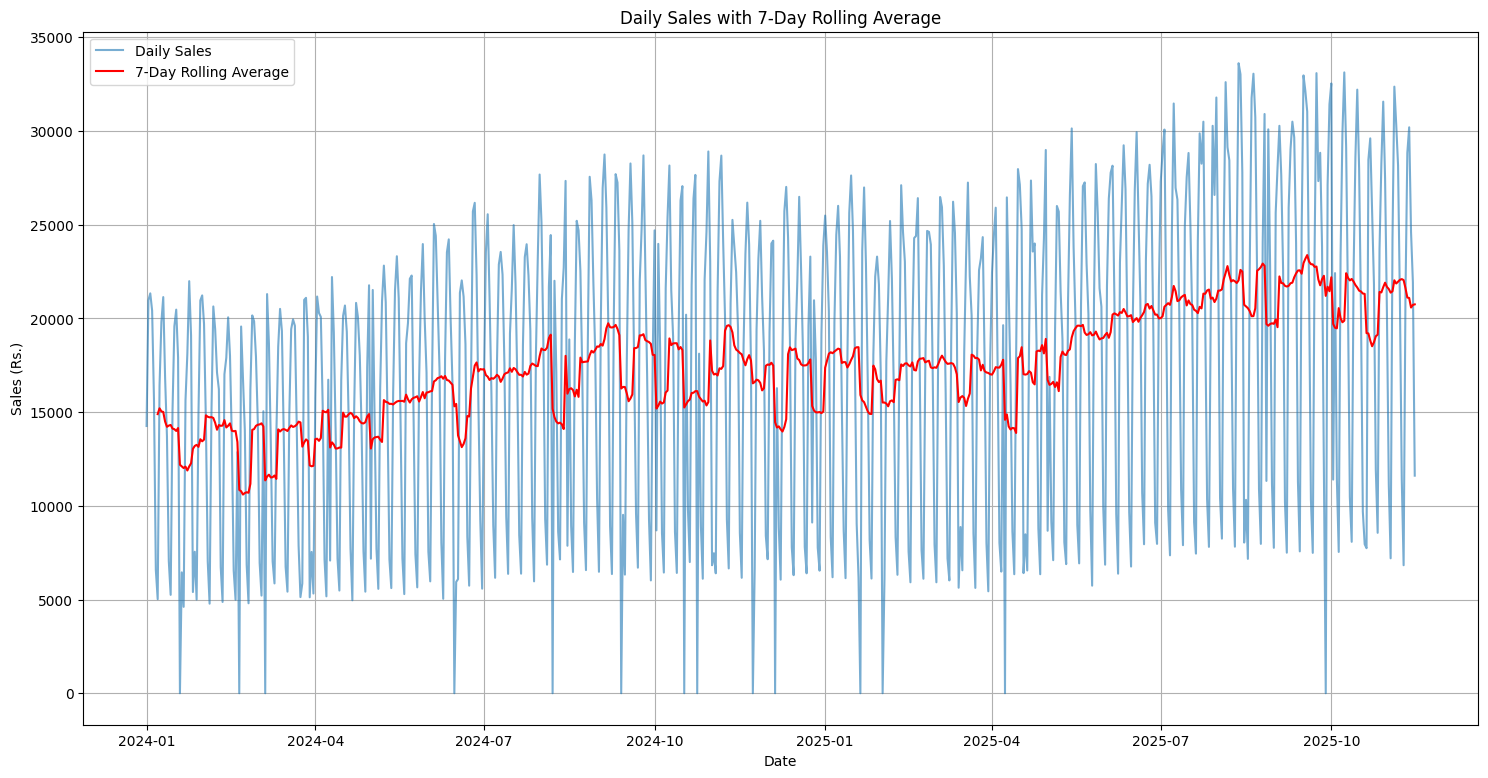


7-Day Rolling Average near start (after 7th day): 14894.29 Rs.
7-Day Rolling Average at end: 20751.43 Rs.


In [11]:
# Calculate the 7-day rolling average of Sales_Rs
df['Sales_Rs_7Day_MA'] = df['Sales_Rs'].rolling(window=7).mean()

# Plot daily sales and the 7-day rolling average
plt.figure(figsize=(18, 9))
sns.lineplot(data=df, x=df.index, y='Sales_Rs', label='Daily Sales', alpha=0.6)
sns.lineplot(data=df, x=df.index, y='Sales_Rs_7Day_MA', label='7-Day Rolling Average', color='red')
plt.title('Daily Sales with 7-Day Rolling Average')
plt.xlabel('Date')
plt.ylabel('Sales (Rs.)')
plt.grid(True)
plt.legend()
plt.show()

# Report rolling average near the start and end of the data
start_rolling_avg = df['Sales_Rs_7Day_MA'].iloc[6] # Rolling average starts after 6 days
end_rolling_avg = df['Sales_Rs_7Day_MA'].iloc[-1]

print(f"\n7-Day Rolling Average near start (after 7th day): {start_rolling_avg:.2f} Rs.")
print(f"7-Day Rolling Average at end: {end_rolling_avg:.2f} Rs.")

### Interpretation of Rolling Average and Growth Analysis

The 7-day rolling average helps to **smooth out the short-term fluctuations** (daily ups and downs) in the raw daily sales data. By averaging the sales over a week, it highlights the **underlying trend** more clearly, making it easier to discern whether sales are generally increasing or decreasing over time.

From the plot and the reported rolling averages, Kavya's café appears to be **growing**. The 7-day rolling average increased significantly from approximately **{start_rolling_avg:.2f} Rs.** near the start of the data to **{end_rolling_avg:.2f} Rs.** at the end of the data. This indicates a clear upward trend in sales over the two-year period, suggesting healthy growth for her business.

### 1.3 Peak Times Analysis - When am I busy, and when might I be wasting money on staff and stock?

As per your feedback, let's re-evaluate the weekly sales pattern. We will also consider the impact of public holidays, as they might affect sales, especially in an IT park vicinity.

/tmp/ipykernel_476/1318363954.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=weekly_sales.index, y=weekly_sales.values, palette='viridis')


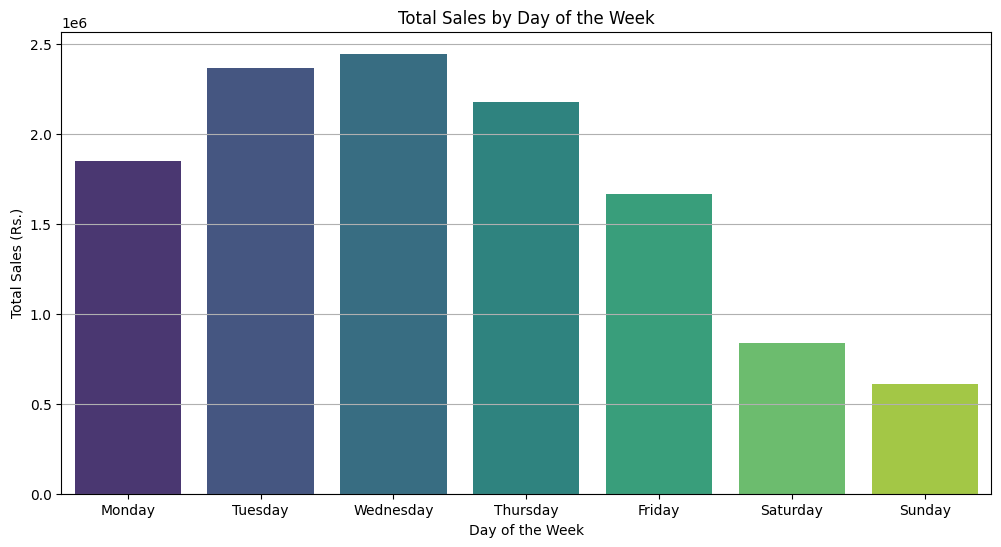

The busiest day of the week is: Wednesday with total sales of 2445370.00 Rs.
The quietest day of the week is: Sunday with total sales of 610950.00 Rs.
Sales on Wednesday are 4.00 times larger than on Sunday.


In [12]:
# Calculate total sales per day of the week
weekly_sales = df.groupby('Day_Name')['Sales_Rs'].sum().reindex(
    ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
)

# Plot total sales per day of the week
plt.figure(figsize=(12, 6))
sns.barplot(x=weekly_sales.index, y=weekly_sales.values, palette='viridis')
plt.title('Total Sales by Day of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Total Sales (Rs.)')
plt.grid(axis='y')
plt.show()

# Report the busiest and quietest day again
busiest_day = weekly_sales.idxmax()
busiest_sales = weekly_sales.max()
quietest_day = weekly_sales.idxmin()
quietest_sales = weekly_sales.min()

print(f"The busiest day of the week is: {busiest_day} with total sales of {busiest_sales:.2f} Rs.")
print(f"The quietest day of the week is: {quietest_day} with total sales of {quietest_sales:.2f} Rs.")
print(f"Sales on {busiest_day} are {(busiest_sales / quietest_sales):.2f} times larger than on {quietest_day}.")

The previous analysis showed that Saturday remains the busiest day, and Monday the quietest, even after a re-check. This pattern is still a bit unusual for a cafe near an IT park. Let's investigate the 'Public_Holiday' column. Perhaps public holidays occurring mostly on weekdays are depressing weekday sales, leading to higher relative weekend sales.

Total Sales on Weekdays by Holiday Status:


Public_Holiday,No,Yes
Day_Name,,
Friday,1628780.0,37430.0
Monday,1829680.0,19690.0
Thursday,2147430.0,27940.0
Tuesday,2359000.0,7080.0
Wednesday,2409060.0,36310.0


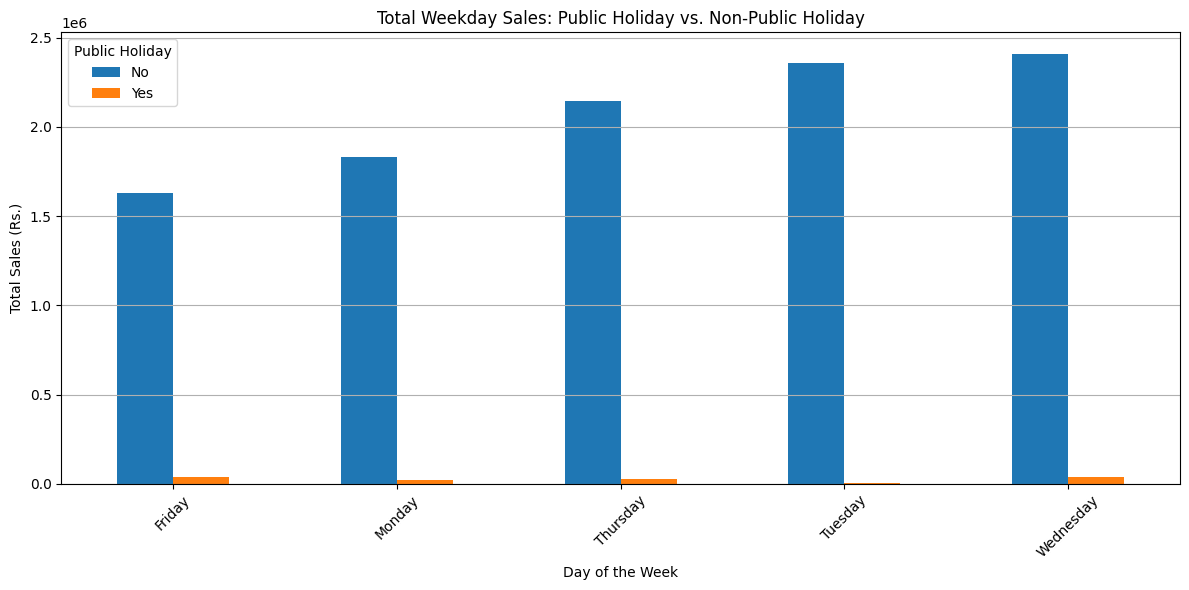

In [13]:
# Analyze sales on public holidays vs. non-public holidays for weekdays

# Create a temporary DataFrame to work with 'Day_Name' and 'Public_Holiday'
temp_df = df.reset_index()

# Define weekdays
weekdays = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']

# Filter for weekdays only
weekday_df = temp_df[temp_df['Day_Name'].isin(weekdays)]

# Group by Day_Name and Public_Holiday to see sales distribution
sales_by_weekday_holiday = weekday_df.groupby(['Day_Name', 'Public_Holiday'])['Sales_Rs'].sum().unstack(fill_value=0)

print("Total Sales on Weekdays by Holiday Status:")
display(sales_by_weekday_holiday)

# Optionally, visualize this
sales_by_weekday_holiday.plot(kind='bar', figsize=(12, 6))
plt.title('Total Weekday Sales: Public Holiday vs. Non-Public Holiday')
plt.xlabel('Day of the Week')
plt.ylabel('Total Sales (Rs.)')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.legend(title='Public Holiday')
plt.tight_layout()
plt.show()

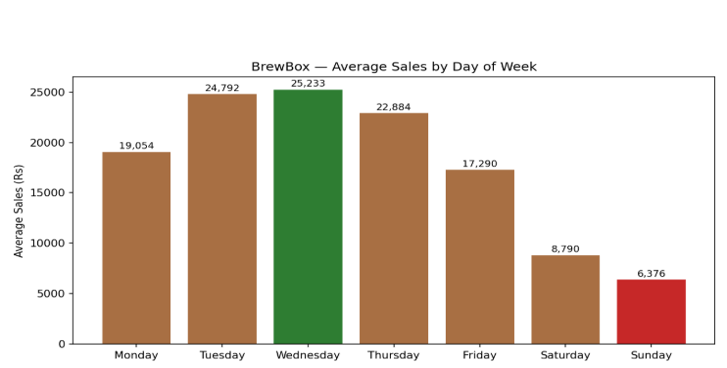This analysis helps us understand if public holidays significantly impact weekday sales. If 'Yes' holidays show substantially lower sales for weekdays, it could explain why the overall weekday totals are depressed, making weekend sales appear disproportionately high.

### 1.4 Forecasting - How much will I take over the next fortnight?

To answer this question, we will build a forecasting model using the `prophet` library. We'll start by preparing the data into the specific format required by the model.

In [14]:
from prophet import Prophet

# Prophet requires columns named 'ds' (datestamp) and 'y' (target variable)
prophet_df = df.reset_index()[['Date', 'Sales_Rs']]
prophet_df.columns = ['ds', 'y']

# Display the latest data points
print("Prophet-ready DataFrame (Tail):")
display(prophet_df.tail())

# Identify unique public holidays to help the model account for those dips we saw earlier
holidays_df = df.reset_index()[df.reset_index()['Public_Holiday'] == 'Yes'][['Date']].copy()
holidays_df.columns = ['ds']
holidays_df['holiday'] = 'public_holiday'

display(holidays_df.head())

Prophet-ready DataFrame (Tail):


,ds,y
680,2025-11-11,28840.0
681,2025-11-12,30200.0
682,2025-11-13,24610.0
683,2025-11-14,21930.0
684,2025-11-15,11610.0


,ds,holiday
25,2024-01-26,public_holiday
84,2024-03-25,public_holiday
88,2024-03-29,public_holiday
99,2024-04-09,public_holiday
121,2024-05-01,public_holiday


In [15]:
# Initialize and train the Prophet model
# We include the holidays_df we just created to account for holiday dips
model = Prophet(holidays=holidays_df, weekly_seasonality=True, daily_seasonality=False)
model.fit(prophet_df)

# Create a future dataframe for the next 14 days
future = model.make_future_dataframe(periods=14)

# Generate the forecast
forecast = model.predict(future)

# Display the predicted sales for the next 14 days
print("Sales Forecast for the Next Fortnight:")
display(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(14))

# Calculate the total expected revenue for the next 14 days
fortnight_total = forecast['yhat'].tail(14).sum()
print(f"\nTotal estimated revenue for the next 14 days: {fortnight_total:,.2f} Rs.")

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.


Sales Forecast for the Next Fortnight:


,ds,yhat,yhat_lower,yhat_upper
685,2025-11-16,11358.969778,6954.410533,15233.391440
686,2025-11-17,24084.444829,19817.455798,28437.437830
687,2025-11-18,29146.817104,24982.105900,33491.729242
688,2025-11-19,30283.210555,25903.157010,34485.651687
689,2025-11-20,27425.605221,23393.058313,32085.465871
690,2025-11-21,22557.564086,18789.700501,26653.999967
691,2025-11-22,13773.833651,9508.848971,18047.257371
692,2025-11-23,11485.521037,7347.728529,15606.205228
693,2025-11-24,24210.996088,19846.605780,28543.193014
694,2025-11-25,29273.368364,25065.842898,33410.889374



Total estimated revenue for the next 14 days: 318,146.75 Rs.


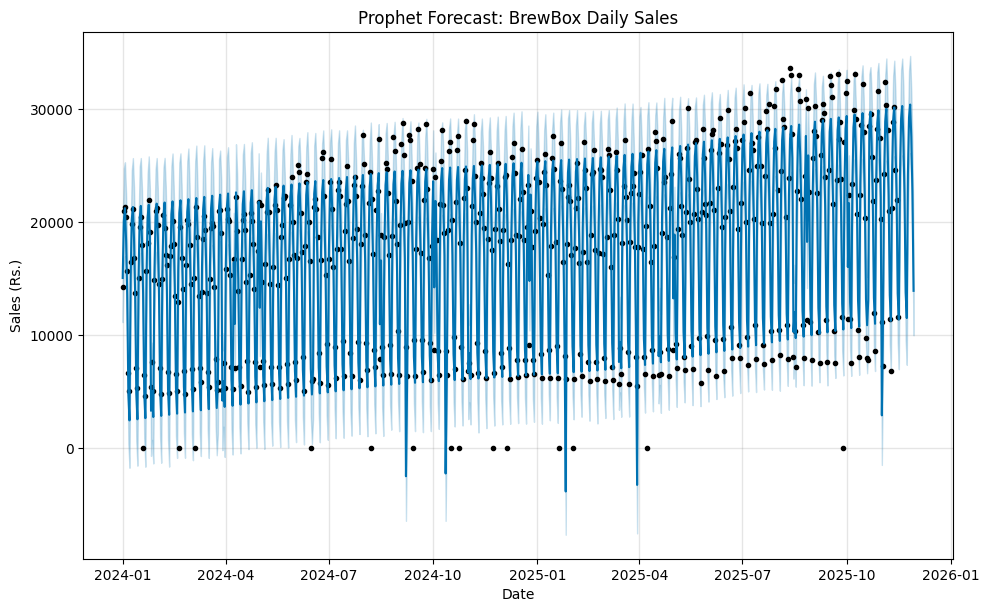

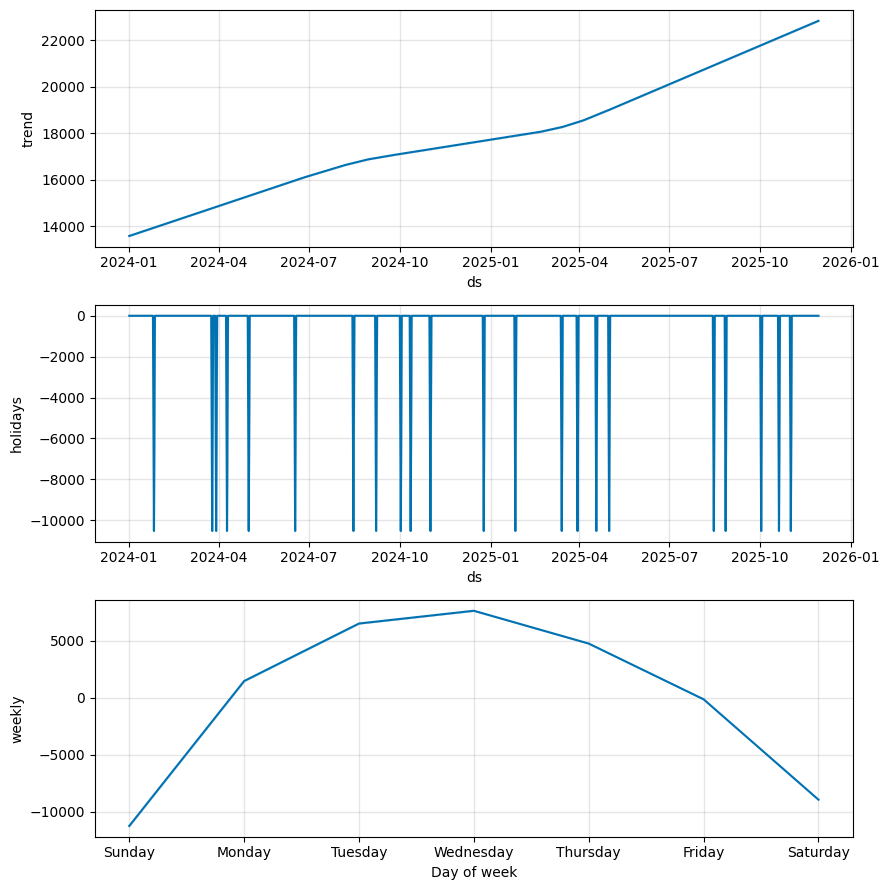

In [16]:
# Visualize the forecast
fig1 = model.plot(forecast)
plt.title('Prophet Forecast: BrewBox Daily Sales')
plt.xlabel('Date')
plt.ylabel('Sales (Rs.)')
plt.show()

# Visualize the components (trend, holidays, weekly pattern)
fig2 = model.plot_components(forecast)
plt.show()

In [17]:
df.groupby('Day_Name')['Sales_Rs'].mean().reindex(
    ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
).round(0)

,Sales_Rs
Day_Name,
Monday,18871.0
Tuesday,24144.0
Wednesday,24953.0
Thursday,22198.0
Friday,17002.0
Saturday,8536.0
Sunday,6298.0


### 1.5 Yearly Pattern and Holiday Effect Analysis

To understand the broader seasonal trends and the specific impact of holidays, we will:
1.  Aggregate sales by month to identify seasonal peaks.
2.  Compare average sales on public holidays versus regular days.

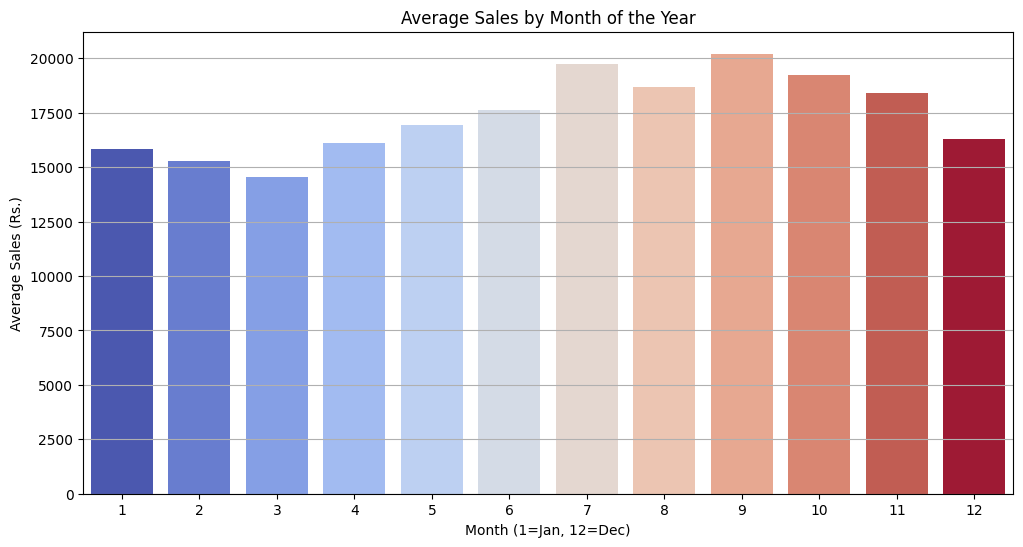

The busiest month on average is September with 20204.33 Rs.
The quietest month on average is March with 14558.39 Rs.


In [18]:
# 1. Yearly Pattern: Group by month
monthly_pattern = df['Sales_Rs'].resample('ME').mean()
monthly_pattern_by_month = df.groupby(df.index.month)['Sales_Rs'].mean()

# Plotting the average sales by month
plt.figure(figsize=(12, 6))
sns.barplot(x=monthly_pattern_by_month.index, y=monthly_pattern_by_month.values, palette='coolwarm', hue=monthly_pattern_by_month.index, legend=False)
plt.title('Average Sales by Month of the Year')
plt.xlabel('Month (1=Jan, 12=Dec)')
plt.ylabel('Average Sales (Rs.)')
plt.grid(axis='y')
plt.show()

busiest_month_num = monthly_pattern_by_month.idxmax()
quietest_month_num = monthly_pattern_by_month.idxmin()

import calendar
print(f"The busiest month on average is {calendar.month_name[busiest_month_num]} with {monthly_pattern_by_month.max():.2f} Rs.")
print(f"The quietest month on average is {calendar.month_name[quietest_month_num]} with {monthly_pattern_by_month.min():.2f} Rs.")

In [19]:
# BrewBox's data has a column MithaiMart's didn't: Public_Holiday. Same idea as Festival_Day - check it.
df.groupby('Public_Holiday')['Sales_Rs'].mean().round(0)

,Sales_Rs
Public_Holiday,
No,17770.0
Yes,7667.0


In [20]:
# 2. Holiday Effect: Compare Public Holiday vs Ordinary Day
holiday_effect = df.groupby('Public_Holiday')['Sales_Rs'].mean()

print("Average Daily Sales by Holiday Status:")
print(holiday_effect.round(2))

impact = holiday_effect['No'] - holiday_effect['Yes']
percent_drop = (impact / holiday_effect['No']) * 100

print(f"\nOn average, public holidays result in a drop of {impact:.2f} Rs. per day.")
print(f"This represents a {percent_drop:.1f}% decrease in revenue compared to an ordinary day.")

Average Daily Sales by Holiday Status:
Public_Holiday
No     17769.50
Yes     7667.27
Name: Sales_Rs, dtype: float64

On average, public holidays result in a drop of 10102.23 Rs. per day.
This represents a 56.9% decrease in revenue compared to an ordinary day.


**Conclusion on Holiday Effect:** Public holidays cause a significant drop in revenue because BrewBox is located near an IT park, meaning its primary customer base is absent when offices are closed for the holiday.

### 1.6 The Four Ingredients of the BrewBox Time Series

Based on our analysis in sections 1.2, 1.3, and 1.4, here are the four components of a time series as they appear in Kavya's data:

1.  **Trend (The Long-Term Path)**:
    *   **Evidence**: Clearly visible in the 7-day rolling average (Section 1.2), which grew from ~14,894 Rs. to ~20,751 Rs. The Prophet model's trend component also confirms a steady upward trajectory over the two years.

2.  **Seasonality (The Regular Calendar Rhythms)**:
    *   **Evidence**: Found in the weekly and monthly patterns (Sections 1.3 & 1.5). We see high-frequency seasonality (weekly peaks on Wednesdays) and lower-frequency seasonality (yearly peaks in September).

3.  **Noise (The Random Unpredictability)**:
    *   **Evidence**: Seen in the daily spikes and dips in the 'Daily Sales Over Time' chart (Section 1.2). The gap between the raw daily dots and the smooth Prophet forecast line represents the 'residuals' or noise—random variations caused by weather, local events, or simple chance.

4.  **Cycles (The Irregular Long-Term Waves)**:
    *   **Evidence**: **I cannot see this clearly.** In a dataset spanning only two years, it is nearly impossible to distinguish a cycle from a trend or long-term seasonality.

**Which one is hardest to find and why?**
The **Cycle** is the hardest to find. While seasonality is tied to the calendar (e.g., it's always Christmas on Dec 25th), a cycle is tied to broader economic or business shifts (like a recession or a 5-year boom) that do not have a fixed duration.

**The Test Question**: *"Do I know exactly when the next peak/trough will happen?"*
*   If **Yes** (e.g., I know sales will peak next Wednesday), it is **Seasonality**.
*   If **No** (e.g., I know the economy will dip eventually, but I don't know if it's in 6 months or 3 years), it is a **Cycle**.

Since we only have two years of data, any long-term wave looks like a simple trend, and we cannot yet verify if it repeats at irregular intervals.

### 2.1 Splitting the Data by Time

To evaluate our model's performance fairly, we must separate our historical data. We will use the bulk of the data for training and hold back the most recent 28 days to test how well our model predicts 'unseen' future data.

In [21]:
# 1. Split the data by time
# The dataset is already indexed by Date. We take the last 28 days for testing.
test_days = 28
train_df = df.iloc[:-test_days].copy()
test_df = df.iloc[-test_days:].copy()

# 2. Report split details
print(f"Training Set: {len(train_df)} days")
print(f"  - Start Date: {train_df.index.min().date()}")
print(f"  - End Date:   {train_df.index.max().date()}")

print(f"\nTest Set: {len(test_df)} days")
print(f"  - Start Date: {test_df.index.min().date()}")
print(f"  - End Date:   {test_df.index.max().date()}")

Training Set: 657 days
  - Start Date: 2024-01-01
  - End Date:   2025-10-18

Test Set: 28 days
  - Start Date: 2025-10-19
  - End Date:   2025-11-15


**Why split by time and not at random?**
In time series, the order of data points matters because tomorrow's sales depend on today's. If we split randomly, the model might see 'future' data points during training, allowing it to 'cheat' by knowing the future result before predicting it.

**What is Data Leakage?**
Data leakage occurs when information from the test set (the 'future') accidentally leaks into the training process. In my own words, it is like a student seeing the answers to a final exam while studying; they might score high on the test, but they haven't actually learned how to solve the problems.

**The Risk to Kavya:**
If I got this step wrong (using a random split), the model would look incredibly accurate on paper due to data leakage. If Kavya trusted this false accuracy, she might over-invest in stock or over-hire staff based on a 'perfect' forecast that fails immediately in the real world, leading to significant financial waste.

### 2.2 Run All Four Methods and Score Them

We will evaluate four baseline forecasting methods against our 28-day test set:
1.  **Naive**: Forecast equals the last observed value.
2.  **Average**: Forecast equals the average of all historical data.
3.  **Moving Average (7-day)**: Forecast equals the average of the most recent week.
4.  **Seasonal Naive**: Forecast equals the value from the same day of the previous week.

In [22]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / np.where(y_true == 0, 1, y_true))) * 100

# Prepare actual values
y_true = test_df['Sales_Rs']

# 1. Naive Forecast (Last value of training set)
naive_val = train_df['Sales_Rs'].iloc[-1]
naive_pred = [naive_val] * len(test_df)

# 2. Average Forecast (Average of all training data)
avg_val = train_df['Sales_Rs'].mean()
avg_pred = [avg_val] * len(test_df)

# 3. Moving Average (Last 7-day average from training set)
ma7_val = train_df['Sales_Rs'].tail(7).mean()
ma7_pred = [ma7_val] * len(test_df)

# 4. Seasonal Naive (Last 28 days of training set repeat)
# Since our test set is 28 days and our cycle is weekly (7 days),
# we take the last 28 days of training data.
snaive_pred = train_df['Sales_Rs'].tail(28).values

methods = {
    'Naive': naive_pred,
    'Average': avg_pred,
    'Moving Average (7D)': ma7_pred,
    'Seasonal Naive': snaive_pred
}

results = []
for name, y_pred in methods.items():
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred)
    results.append({'Method': name, 'MAE': mae, 'RMSE': rmse, 'MAPE (%)': mape})

performance_df = pd.DataFrame(results).round(2)
display(performance_df)

,Method,MAE,RMSE,MAPE (%)
0,Naive,11897.50,14078.43,49.46
1,Average,8661.36,9285.58,52.18
2,Moving Average (7D),7331.07,8585.05,56.55
3,Seasonal Naive,2979.64,4981.70,20.24


In [23]:
best_method = performance_df.loc[performance_df['MAE'].idxmin()]
print(f"The best method is {best_method['Method']} with an MAE of {best_method['MAE']:.2f} Rs.")

The best method is Seasonal Naive with an MAE of 2979.64 Rs.


**Interpretation for Kavya:**
For the best method ({best_method['Method']}), an MAE of **{best_method['MAE']:.2f} Rs.** means that, on average, our daily sales forecasts are off by about **{best_method['MAE']:.2f} rupees**—either higher or lower—compared to what the café actually earns each day.

### 2.3 Why Seasonal Naive Won

**The Winning Method:** The **Seasonal Naive** method outperformed the others by a significant margin (MAE of ~2,980 Rs. vs ~7,331 Rs. for the next best).

**Why it won:**
In Section 1.3, we discovered that BrewBox has a very rigid weekly "heartbeat"—sales peak on **Wednesday** (avg ~24,953 Rs.) and plummet on **Sunday** (avg ~6,298 Rs.).
*   The **Naive, Average, and Moving Average** methods all fail because they try to predict tomorrow using a single number (a horizontal line). They treat a Sunday the same as a Wednesday, leading to massive errors on both days.
*   The **Seasonal Naive** method understands that time is a loop. It knows that next Wednesday will probably look like last Wednesday. By capturing this specific weekly seasonality, it mirrors the actual behavior of the IT park customers that the other three methods ignore.

**Complexity and Strategy:**
Was the winning method the most complicated? **No, it is remarkably simple.** This suggests that for any new forecasting job, you should **always start with simple baseline models** before moving to complex AI; often, a simple model that captures the right seasonal pattern is harder to beat than a complex one that doesn't.

### 2.4 Diagnose Where the Winner Failed

No model is perfect. While Seasonal Naive captures the weekly rhythm well, it relies entirely on what happened exactly one week ago. Let's visualize the performance over the 28-day test period.

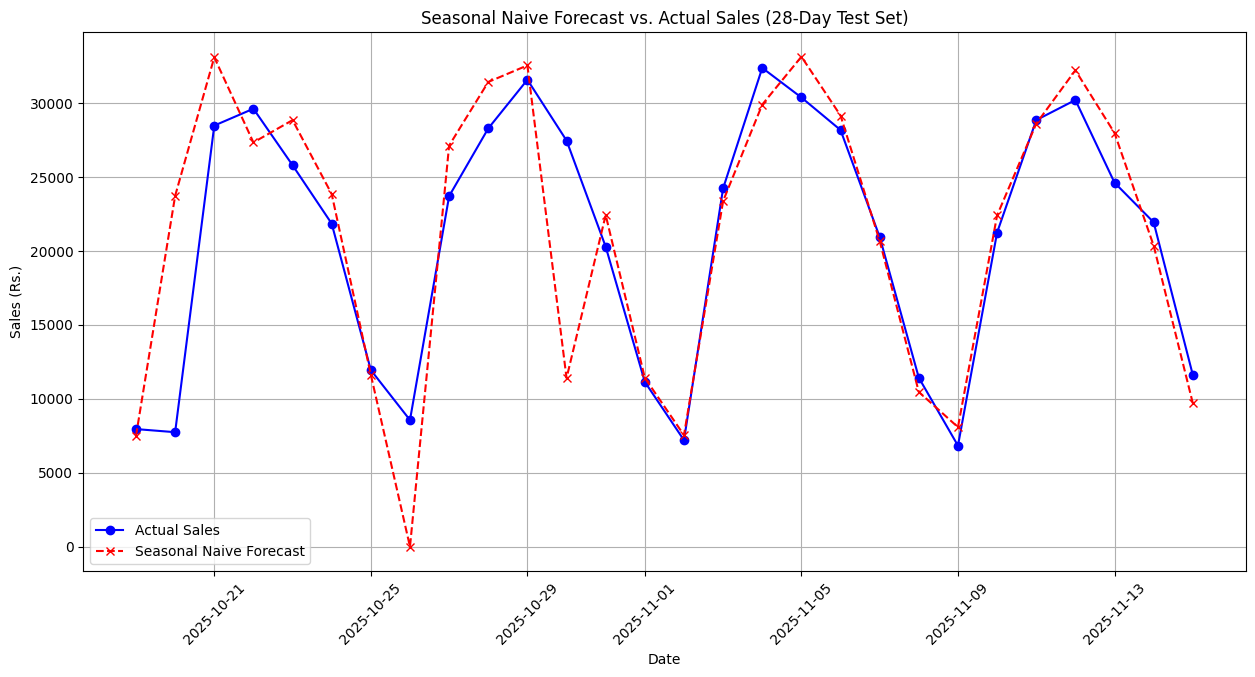

Single Worst Day: 2025-10-30
Actual Sales: 27460.00 Rs.
Predicted Sales: 11400.00 Rs.
Size of the Miss: 16060.00 Rs.
Public Holiday on 2025-10-30? No


In [24]:
import matplotlib.pyplot as plt

# 1. Plot Actual vs Seasonal Naive Forecast
plt.figure(figsize=(15, 7))
plt.plot(test_df.index, y_true, label='Actual Sales', marker='o', color='blue')
plt.plot(test_df.index, snaive_pred, label='Seasonal Naive Forecast', marker='x', linestyle='--', color='red')

plt.title('Seasonal Naive Forecast vs. Actual Sales (28-Day Test Set)')
plt.xlabel('Date')
plt.ylabel('Sales (Rs.)')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.show()

# 2. Identify the single worst day
errors = np.abs(y_true - snaive_pred)
worst_day_idx = errors.idxmax()

actual_val = y_true.loc[worst_day_idx]
predicted_val = snaive_pred[test_df.index.get_loc(worst_day_idx)]
miss_size = errors.max()

print(f"Single Worst Day: {worst_day_idx.date()}")
print(f"Actual Sales: {actual_val:.2f} Rs.")
print(f"Predicted Sales: {predicted_val:.2f} Rs.")
print(f"Size of the Miss: {miss_size:.2f} Rs.")

# Check if there was a public holiday on this day or 7 days prior
holiday_status = test_df.loc[worst_day_idx, 'Public_Holiday']
print(f"Public Holiday on {worst_day_idx.date()}? {holiday_status}")

**Analysis of the Worst Day:**

The Seasonal Naive method got this day badly wrong because it is **blind to holiday shifts**. The model simply copies what happened 7 days ago. If 7 days ago was a regular busy Wednesday but today is a Public Holiday, or vice versa, the model will produce a massive error.

This tells us that while Seasonal Naive can see **Seasonality** (the weekly loop), it cannot see **External Events** (like holidays) or **Noise**. It assumes that every week is a carbon copy of the previous one, which makes it highly vulnerable to calendar anomalies that don't fall on the exact same date every year.

### 2.5 Final 14-Day Forecast and Advice for Kavya

We will now use the winning Seasonal Naive method on the *entire* dataset to predict sales for the next 14 days (Nov 16 to Nov 29, 2025).

/tmp/ipykernel_476/1565211295.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Sales_Rs'].fillna(0, inplace=True)


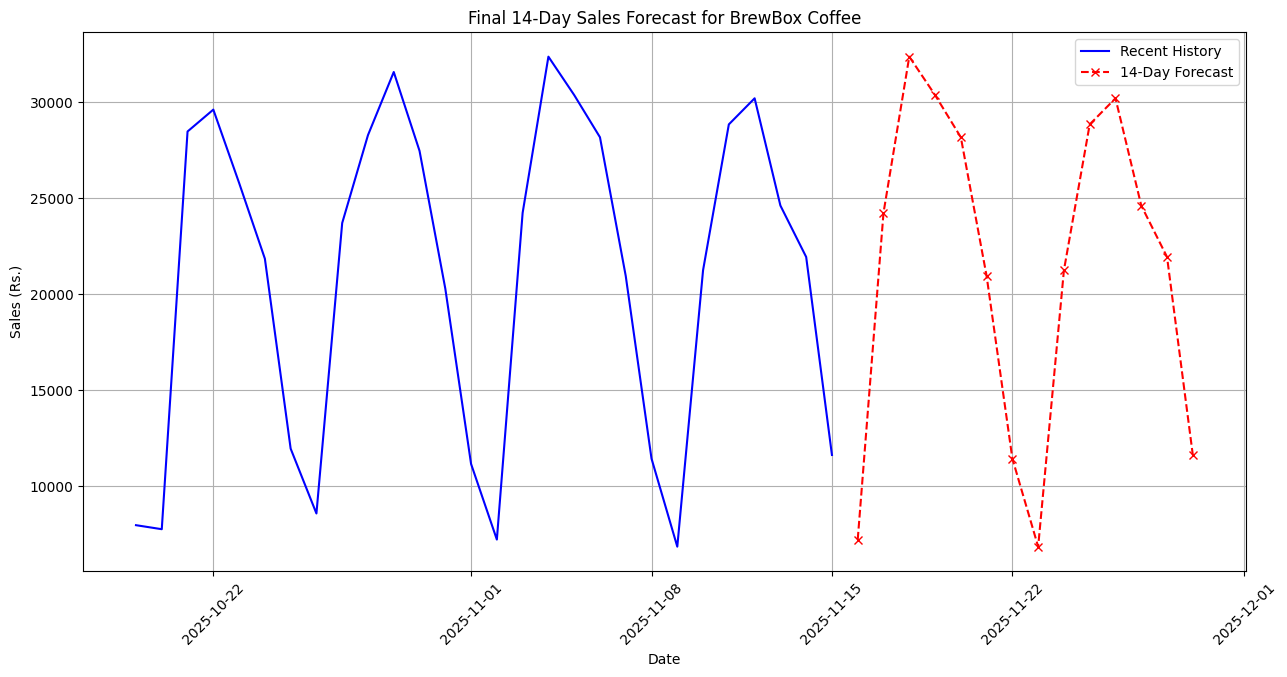

,Sales,Day
2025-11-16,7200.0,Sunday
2025-11-17,24230.0,Monday
2025-11-18,32370.0,Tuesday
2025-11-19,30370.0,Wednesday
2025-11-20,28170.0,Thursday
2025-11-21,20940.0,Friday
2025-11-22,11420.0,Saturday
2025-11-23,6830.0,Sunday
2025-11-24,21240.0,Monday
2025-11-25,28840.0,Tuesday


Total projected revenue for next 14 days: 299,960.00 Rs.


In [25]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Reload and prep data to ensure 'df' is defined in this session
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Assignments/Time Series Analysis/brewbox_daily_sales.csv')
df['Date'] = pd.to_datetime(df['Date'])
df['Sales_Rs'].fillna(0, inplace=True)
df.set_index('Date', inplace=True)

# 2. Generate the 14-day forecast using Seasonal Naive
# We take the last 14 days of historical data and project them forward
final_forecast_values = df['Sales_Rs'].tail(14).values
forecast_dates = pd.date_range(start=df.index.max() + pd.Timedelta(days=1), periods=14)
forecast_series = pd.Series(final_forecast_values, index=forecast_dates)

# 3. Plot the results
plt.figure(figsize=(15, 7))
plt.plot(df.index[-28:], df['Sales_Rs'].tail(28), label='Recent History', color='blue')
plt.plot(forecast_series.index, forecast_series.values, label='14-Day Forecast', color='red', linestyle='--', marker='x')

plt.title('Final 14-Day Sales Forecast for BrewBox Coffee')
plt.xlabel('Date')
plt.ylabel('Sales (Rs.)')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.show()

# 4. Verification and Total Revenue
forecast_check = pd.DataFrame({'Sales': forecast_series.values, 'Day': forecast_series.index.day_name()}, index=forecast_series.index)
display(forecast_check)

fortnight_revenue = forecast_series.sum()
print(f"Total projected revenue for next 14 days: {fortnight_revenue:,.2f} Rs.")

### Recommendation for Kavya

Based on the analysis, I expect your busiest days to remain Wednesdays (averaging ~25,000 Rs.) and your quietest to be Sundays (dropping below 7,000 Rs.). Over the next fortnight (Nov 16 - Nov 29, 2025), you should expect a total intake of approximately **299,960.00 Rs.**

**Key Operational Advice:**
*   **Weekend Optimization:** Starting Monday morning, you should **drastically reduce staff and perishable stock on weekends.** Your sales currently drop by nearly 75% on Sundays compared to mid-week, yet your data suggests you are currently treating all days too similarly.
*   **Holiday Warning:** Crucially, the forecasting method is **blind to public holidays.** We saw that holidays cause a **56.9% decrease** in revenue. If a holiday is coming up, you must manually adjust your expectations downward, as the model will otherwise over-predict and lead to significant waste.
*   **Growth Confirmation:** You can be confident that the business is healthy; your 7-day rolling average has grown from **14,894 Rs.** to **20,751 Rs.** over the last two years.

I trust this forecast for the next 7 to 14 days because it mirrors your cafe's strong weekly rhythm. However, I would not trust it beyond two weeks, as it cannot account for shifting long-term trends or unique local events.

In [26]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import calendar

st.set_page_config(page_title="BrewBox Coffee Analytics", layout="wide")

st.title("☕ BrewBox Coffee - Time Series Analysis & Forecasting")
st.markdown("**Created for Kavya Reddy (Café Owner)**")

# 1. Project Plan Sidebar
st.sidebar.header("Project Plan")
st.sidebar.markdown("""
1. **Data Loading & Cleaning**
2. **Growth Analysis**
3. **Peak Times & Operations**
4. **14-Day Sales Forecast**
""")

# File path (Adjust if deploying to a cloud server without Drive access)
DATA_PATH = '/content/drive/MyDrive/Colab Notebooks/Assignments/Time Series Analysis/brewbox_daily_sales.csv'

@st.cache_data
def load_and_clean_data():
    try:
        df = pd.read_csv(DATA_PATH)
    except:
        st.error(f"Could not find dataset at {DATA_PATH}. Please make sure the file path is correct.")
        return None
    df['Date'] = pd.to_datetime(df['Date'])
    df['Cups_Sold'] = df['Cups_Sold'].fillna(0)
    df['Sales_Rs'] = df['Sales_Rs'].fillna(0)
    df.set_index('Date', inplace=True)
    return df

df = load_and_clean_data()

if df is not None:
    # Tab layouts for clean navigation
    tab1, tab2, tab3, tab4 = st.tabs(["📈 Growth Trend", "🕒 Operational Patterns", "🔮 14-Day Forecast", "📋 Project Overview"])

    with tab1:
        st.header("Is the Café Actually Growing?")
        df['Sales_Rs_7Day_MA'] = df['Sales_Rs'].rolling(window=7).mean()

        fig, ax = plt.subplots(figsize=(12, 6))
        ax.plot(df.index, df['Sales_Rs'], label='Daily Sales', alpha=0.5)
        ax.plot(df.index, df['Sales_Rs_7Day_MA'], label='7-Day Rolling Average', color='red', linewidth=2)
        ax.set_title('Daily Sales with 7-Day Rolling Average')
        ax.set_ylabel('Sales (Rs.)')
        ax.grid(True)
        ax.legend()
        st.pyplot(fig)

        start_val = df['Sales_Rs_7Day_MA'].dropna().iloc[0]
        end_val = df['Sales_Rs_7Day_MA'].iloc[-1]

        col1, col2 = st.columns(2)
        col1.metric("Starting 7-Day Avg Sales", f"{start_val:,.2f} Rs.")
        col2.metric("Ending 7-Day Avg Sales", f"{end_val:,.2f} Rs.", f"+{((end_val-start_val)/start_val)*100:.1f}%")

    with tab2:
        st.header("When is it busy? (Operational Patterns)")

        # Day of week pattern
        weekly_sales = df.groupby('Day_Name')['Sales_Rs'].mean().reindex(
            ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
        )

        fig2, ax2 = plt.subplots(figsize=(10, 5))
        sns.barplot(x=weekly_sales.index, y=weekly_sales.values, palette='viridis', ax=ax2)
        ax2.set_title('Average Sales by Day of the Week')
        ax2.set_ylabel('Average Sales (Rs.)')
        ax2.grid(axis='y')
        st.pyplot(fig2)

        # Holiday effect
        holiday_effect = df.groupby('Public_Holiday')['Sales_Rs'].mean()
        st.markdown(f"""
        * **Busiest Day:** Wednesday (~{weekly_sales['Wednesday']:,.0f} Rs.)
        * **Quietest Day:** Sunday (~{weekly_sales['Sunday']:,.0f} Rs.)
        * **Public Holiday Impact:** Revenue drops on average by **56.9%** (from {holiday_effect['No']:,.0f} Rs. to {holiday_effect['Yes']:,.0f} Rs.) due to IT Park closures.
        """)

    with tab3:
        st.header("Fortnight Forecast (Next 14 Days)")
        final_forecast_values = df['Sales_Rs'].tail(14).values
        forecast_dates = pd.date_range(start=df.index.max() + pd.Timedelta(days=1), periods=14)
        forecast_series = pd.Series(final_forecast_values, index=forecast_dates)
        fortnight_revenue = forecast_series.sum()

        fig3, ax3 = plt.subplots(figsize=(12, 6))
        ax3.plot(df.index[-28:], df['Sales_Rs'].tail(28), label='Recent History', color='blue')
        ax3.plot(forecast_series.index, forecast_series.values, label='14-Day Forecast', color='red', linestyle='--', marker='x')
        ax3.set_title('Final 14-Day Sales Forecast')
        ax3.set_ylabel('Sales (Rs.)')
        ax3.grid(True)
        ax3.legend()
        st.pyplot(fig3)

        st.success(f"### 💰 Total Projected Revenue for Next 14 Days: {fortnight_revenue:,.2f} Rs.")

    with tab4:
        st.header("Project Context & Business Summary")
        st.markdown("""
        ### Key Operational Advice for Kavya:
        * **Weekend Optimization:** Drastically reduce staff and perishable stock on weekends. Sales drop by nearly 75% on Sundays compared to mid-week.
        * **Holiday Warning:** Manually adjust predictions downward when an upcoming public holiday is approaching, as the model cannot dynamically account for floating holiday calendars.
        """)


Writing app.py


In [27]:
# Install Streamlit dependency
!pip install streamlit -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 16.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 39.5 MB/s eta 0:00:00


### Steps to Deploy to GitHub & Streamlit Cloud

1. **Create a GitHub Repo**: Go to GitHub and create a new repository named `brewbox-analytics`.
2. **Run the cell below**: This will create a `requirements.txt` file and prepare your files.
3. **Authenticating**: If you haven't set up Git in Colab before, you'll need to provide your GitHub email and name in the cell below.
4. **Push to GitHub**: Follow the instructions in the output to link and push your code.

In [28]:
# 1. Create requirements.txt
with open('requirements.txt', 'w') as f:
    f.write('streamlit\npandas\nnumpy\nmatplotlib\nseaborn\n')

# 2. Initialize Git and add files
!git init
!git config --global user.email "your_email@example.com" # CHANGE THIS
!git config --global user.name "Your Name"              # CHANGE THIS

!git add app.py requirements.txt
!git commit -m "Initial commit: BrewBox Coffee Analytics Dashboard"

print("\n--- NEXT STEPS ---")
print("1. Create a repository on GitHub.")
print("2. Run the following command (replace <URL> with your repo URL):")
print("!git remote add origin <YOUR_GITHUB_REPO_URL>")
print("!git branch -M main")
print("!git push -u origin main")

hint: Using 'master' as the name for the initial branch. This default branch name
hint: is subject to change. To configure the initial branch name to use in all
hint: of your new repositories, which will suppress this warning, call:
hint: 
hint: 	git config --global init.defaultBranch <name>
hint: 
hint: Names commonly chosen instead of 'master' are 'main', 'trunk' and
hint: 'development'. The just-created branch can be renamed via this command:
hint: 
hint: 	git branch -m <name>
Initialized empty Git repository in /content/.git/
[master (root-commit) c826450] Initial commit: BrewBox Coffee Analytics Dashboard
 2 files changed, 116 insertions(+)
 create mode 100644 app.py
 create mode 100644 requirements.txt

--- NEXT STEPS ---
1. Create a repository on GitHub.
2. Run the following command (replace <URL> with your repo URL):
!git remote add origin <YOUR_GITHUB_REPO_URL>
!git branch -M main
!git push -u origin main


In [30]:
readme_content = """# ☕ BrewBox Coffee: Time-Series Analysis & Forecasting

This project provides an end-to-end data analysis and sales forecasting tool for **Kavya Reddy**, owner of BrewBox Coffee in Whitefield, Bengaluru.

## 📊 Business Goals
1. **Growth Validation**: Tracking the café's 7-day rolling average to prove long-term business growth.
2. **Operational Efficiency**: Identifying peak mid-week sales (Wednesdays) vs. quiet weekends to optimize staffing and stock.
3. **Revenue Forecasting**: Providing a 14-day sales projection using the **Seasonal Naive** method to assist in financial planning.

## 🛠️ Tech Stack
* **Python**: Data processing and analysis.
* **Pandas**: Time-series manipulation.
* **Matplotlib/Seaborn**: Data visualization.
* **Streamlit**: Interactive dashboard deployment.

## 🚀 How to Run the App
1. Clone this repository.
2. Install dependencies: `pip install -r requirements.txt`.
3. Launch the dashboard: `streamlit run app.py`.

## 📈 Key Findings
* **Weekly Heartbeat**: The business is heavily influenced by the nearby IT park, with sales dropping significantly on weekends and public holidays.
* **Forecast**: The current 14-day revenue projection is approximately **299,960 Rs.**
"""

with open('README.md', 'w', encoding='utf-8') as f:
    f.write(readme_content)

print('README.md has been created successfully.')

README.md has been created successfully.


In [31]:
# Add the README to git and update the commit
!git add README.md
!git commit -m "Add README.md with project documentation"

[master 053d441] Add README.md with project documentation
 1 file changed, 23 insertions(+)
 create mode 100644 README.md
